--- ĐÁNH GIÁ BẰNG PHƯƠNG PHÁP NHÌN HÌNH ---


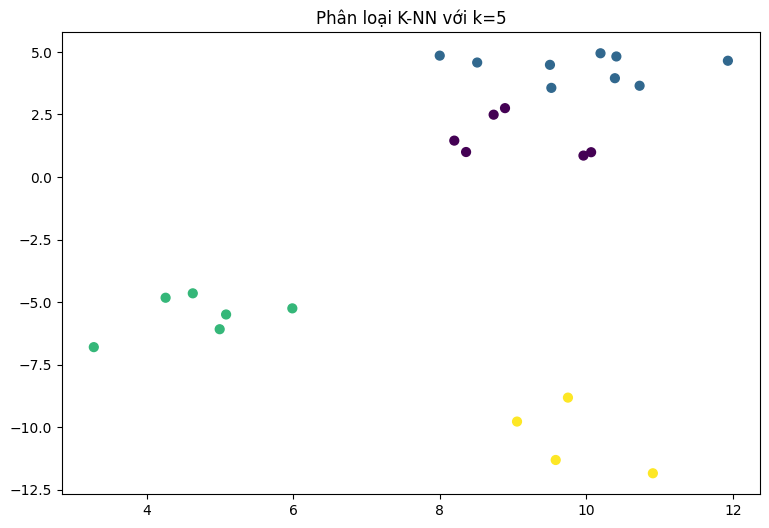

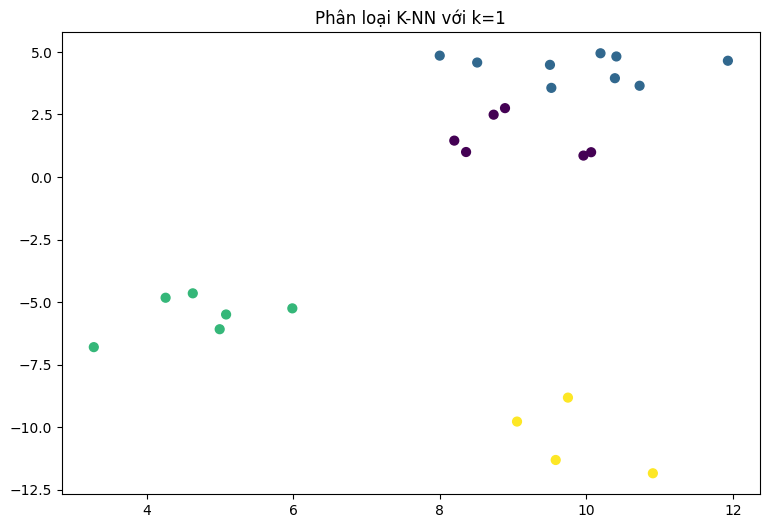


--- ĐÁNH GIÁ TỰ ĐỘNG BẰNG GRIDSEARCHCV ---
Tham số K tốt nhất tìm được là: {'n_neighbors': np.int64(2)}

--- TEST HÀM KNN CÀI ĐẶT THỦ CÔNG ---
Kết quả dán nhãn điểm (1,3) với k=3 là cụm: [0]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# ==========================================
# KHỞI TẠO DỮ LIỆU
# ==========================================
# Khởi tạo tập dữ liệu với 100 mẫu, 4 lớp
X, y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)

# Chia tập dữ liệu thành train (75%) và test (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# ==========================================
# CÁCH 1: ĐÁNH GIÁ TRỌNG SỐ K BẰNG NHÌN HÌNH ĐỒ THỊ
# ==========================================
print("--- ĐÁNH GIÁ BẰNG PHƯƠNG PHÁP NHÌN HÌNH ---")

# Đánh giá với k=5
knn5 = KNeighborsClassifier(5)
knn5.fit(X_train, y_train)
y_pred_5 = knn5.predict(X_test)

plt.figure(figsize=(9,6))
plt.title("Phân loại K-NN với k=5")
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker='o', s=40)
plt.show()

# Đánh giá với k=1
knn1 = KNeighborsClassifier(1)
knn1.fit(X_train, y_train)
y_pred_1 = knn1.predict(X_test)

plt.figure(figsize=(9,6))
plt.title("Phân loại K-NN với k=1")
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker='o', s=40)
plt.show()

# ==========================================
# CÁCH 2: TỰ ĐỘNG TÌM K TỐI ƯU BẰNG GRIDSEARCHCV
# ==========================================
print("\n--- ĐÁNH GIÁ TỰ ĐỘNG BẰNG GRIDSEARCHCV ---")
# Kiểm tra nhiều giá trị k khác nhau
knn_grid = GridSearchCV(estimator=KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1, 10)}, cv=5)
knn_grid.fit(X, y)

print("Tham số K tốt nhất tìm được là:", knn_grid.best_params_)

# ==========================================
# PHẦN MỞ RỘNG: HÀM K-NN TỰ CODE TỪ ĐẦU (FROM SCRATCH)
# ==========================================
print("\n--- TEST HÀM KNN CÀI ĐẶT THỦ CÔNG ---")

def KNN(X_train, X_test, y_train, k):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    y_pred = np.zeros((num_test, num_train))

    for i in range(num_test):
        for j in range(num_train):
            # Tính khoảng cách Euclidean
            y_pred[i, j] = np.sqrt(np.sum(np.power(X_test[i, :] - X_train[j, :], 2)))

    results = []
    for i in range(len(y_pred)):
        zipped = zip(y_pred[i, :], y_train)
        res = sorted(zipped, key=lambda x: x[0])
        results_topk = res[:k]

        classes = {}
        for _, j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1

        results.append(max(classes, key=classes.get))
    return np.array(results)

# Test hàm thủ công với dữ liệu mới
X_blob, y_blob = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, random_state=4)
X_test_manual = np.array([(1, 3)])
results_manual = KNN(X_blob, X_test_manual, y_blob, 3)
print("Kết quả dán nhãn điểm (1,3) với k=3 là cụm:", results_manual)
